# ASSIGNMENT 7 - MLR

# import required libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For model building & evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Statistical analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [4]:
# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# View first few rows
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
# Structure of dataset
df.info()

# Statistical summary
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
# Checking for missing values
df.isnull().sum()


Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

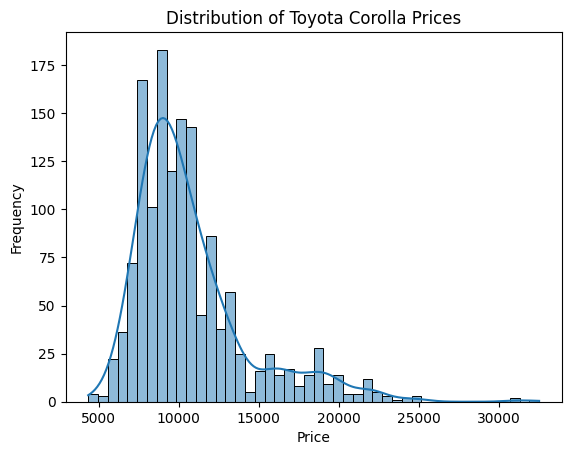

In [7]:
# Histogram of car prices
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Toyota Corolla Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


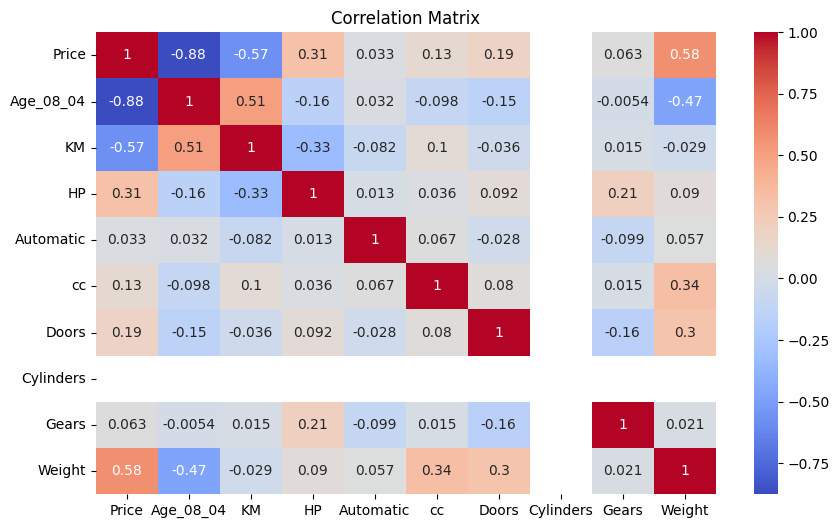

In [8]:
# Correlation heatmap to detect relationships among variables
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


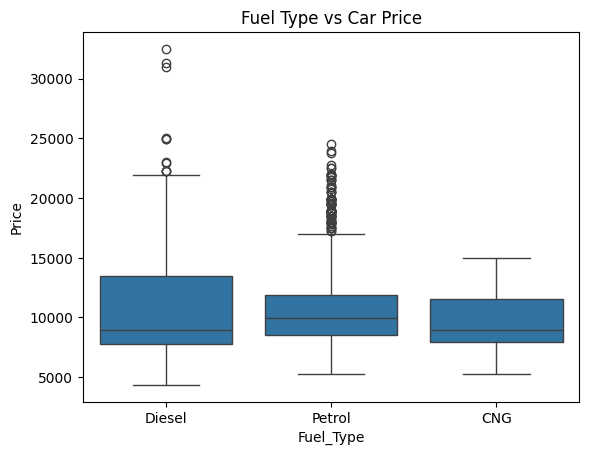

In [9]:
# Boxplot of fuel type vs price
sns.boxplot(x='Fuel_Type', y='Price', data=df)
plt.title("Fuel Type vs Car Price")
plt.show()


In [ ]:
# DATA PREPROCESSING

# Convert categorical variable Fuel_Type into dummy variables
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

# View updated dataset
df.head()


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [ ]:
# SPLITTING DATA INTO TRAIN AND TEST SETS

# Define features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Split data: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# BUILDING MLR

# Create Linear Regression model
model1 = LinearRegression()

# Train the model
model1.fit(X_train, y_train)

# Predict prices on test data
y_pred1 = model1.predict(X_test)



In [ ]:
# Display coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})
coefficients


#  Negative coefficient - price decreases
#  Positive coefficient - price increases

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,1.847411e-12
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [ ]:
# REDUCED FEATURE MODEL

# Selecting important features
selected_features = ['Age_08_04', 'KM', 'HP', 'Weight', 'Automatic']
X2 = df[selected_features]

# Train-test split again
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

# Train reduced model
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

# Predictions
y_pred2 = model2.predict(X_test2)


In [ ]:
# Standardized Linear Regression

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model on standardized data
model3 = LinearRegression()
model3.fit(X_train_scaled, y_train)

# Predictions
y_pred3 = model3.predict(X_test_scaled)


# MLR MODEL EVALUATION

In [ ]:
# MLR Model Evaluation

# Function to evaluate model performance
def evaluate_model(y_true, y_pred):
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

print("Model 1 Performance")
evaluate_model(y_test, y_pred1)

print("\nModel 2 Performance")
evaluate_model(y_test2, y_pred2)

print("\nModel 3 Performance")
evaluate_model(y_test, y_pred3)


Model 1 Performance
MAE : 990.8872739193926
RMSE: 1484.265415329651
R2 Score: 0.8348888040611083

Model 2 Performance
MAE : 1001.7385648668613
RMSE: 1409.0953035297575
R2 Score: 0.8511893129923237

Model 3 Performance
MAE : 990.8872739193971
RMSE: 1484.265415329652
R2 Score: 0.8348888040611081


In [17]:
# Ridge regression model
ridge = Ridge(alpha=10)

# Train Ridge model
ridge.fit(X_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression Performance")
evaluate_model(y_test, y_pred_ridge)
    

Ridge Regression Performance
MAE : 990.6180792393467
RMSE: 1477.689761523612
R2 Score: 0.8363485282657064


In [18]:
# Lasso regression model
lasso = Lasso(alpha=10)

# Train Lasso model
lasso.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Regression Performance")
evaluate_model(y_test, y_pred_lasso)


Lasso Regression Performance
MAE : 992.2092042666142
RMSE: 1474.2550204823071
R2 Score: 0.8371084268156417


# INTERVIEW QUESTIONS

In [ ]:
# Q 1. What is Normalization & Standardization and how is it helpful?

# **Normalization**
# - Scales numerical data into a fixed range, usually between 0 and 1  
# - Helps bring all features to the same scale  
# - Prevents features with large values from dominating the model  
# - Useful when features have different units or ranges  

# **Standardization**
# - Transforms data to have a mean of 0 and a standard deviation of 1  
# - Improves numerical stability of the model  
# - Makes regression coefficients comparable  
# - Essential for Linear Regression, Ridge, and Lasso models 
 
# **Key Difference:**
# - Normalization scales values to a fixed range
# - Standardization centers data around zero with unit variance


# Q 2. What techniques can be used to address multicollinearity in multiple linear regression?

# - Use a correlation matrix to identify highly correlated independent variables  
# - Calculate Variance Inflation Factor (VIF) to detect multicollinearity  
# - Remove or combine highly correlated features  
# - Apply Ridge Regression to reduce coefficient variance  
# - Apply Lasso Regression to perform automatic feature selection  
# - Use Principal Component Analysis (PCA) for dimensionality reduction  
# - Select features based on domain knowledge



## Assumptions Made During the Analysis

# 1. A linear relationship exists between independent variables and price  
# 2. The dataset contains no missing values  
# 3. Errors are independent of each other  
# 4. Variance of errors is constant (homoscedasticity)  
# 5. Multicollinearity is controlled using regularization techniques  

# ## Implications of Assumptions
# - Violation of linearity may reduce prediction accuracy  
# - Presence of multicollinearity affects coefficient interpretation  
# - Heteroscedasticity leads to unreliable confidence intervals  
# - Regularization improves model stability and generalization

